# Exploratory Data Analysis & Visualization - HR Employee Attrition Dataset

This notebook performs Univariate, Bivariate and Multivariate analysis on the IBM HR Analytics Employee Attrition dataset using Seaborn, following the same analysis approach used for the Iris dataset.

In [1]:
# importing the required libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

/Users/manojdannana/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# loading dataset
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [3]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


In [5]:
df.shape

(1470, 35)

* The dataset contains 1470 employee records with 35 features related to demographics, job role and satisfaction.

In [6]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

* All 35 columns are non-null and stored as either integer or object dtype, so no missing value imputation is required.

In [8]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


* Average employee age is around 37 years and average monthly income is around 6500, with a wide spread indicating income varies a lot across job levels.

In [9]:
df.describe(include="O")

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


* The Attrition, BusinessTravel, Department, EducationField, Gender, JobRole, MaritalStatus and OverTime columns are categorical, with Attrition being the target feature.

In [10]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

* There are zero null values in every column, so the dataset is already clean and ready for analysis.

In [11]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

* The target class is imbalanced, with roughly 84% of employees staying (No) and only about 16% leaving (Yes).

In [12]:
df.duplicated().sum()

np.int64(0)

* There are no duplicate rows in the dataset.

In [13]:
df.nunique()

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

* EmployeeCount, Over18 and StandardHours have only a single unique value each, so they carry no useful information and can be dropped later.

### Univariate Analysis

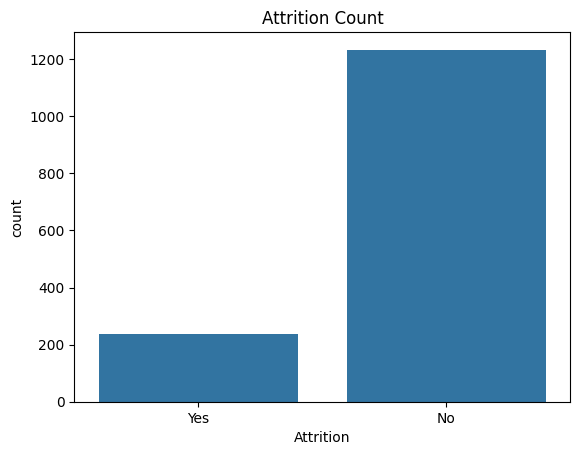

In [14]:
sns.countplot(x='Attrition', data=df)
plt.title("Attrition Count")
plt.show()

* Far fewer employees have attrition = Yes compared to No, confirming the class imbalance seen earlier.

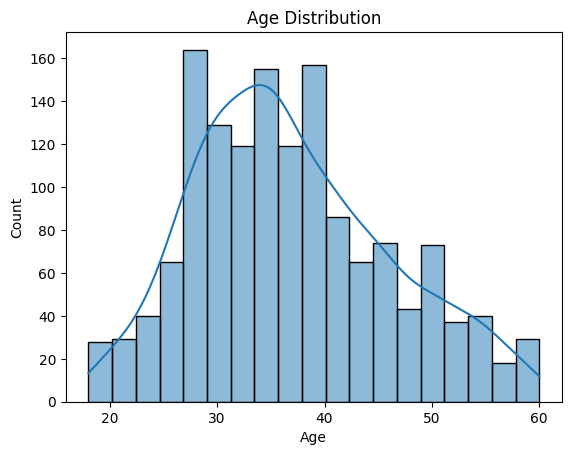

In [15]:
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

* Employee age is roughly normally distributed and concentrated between 28 and 45 years, with a peak around the early 30s.

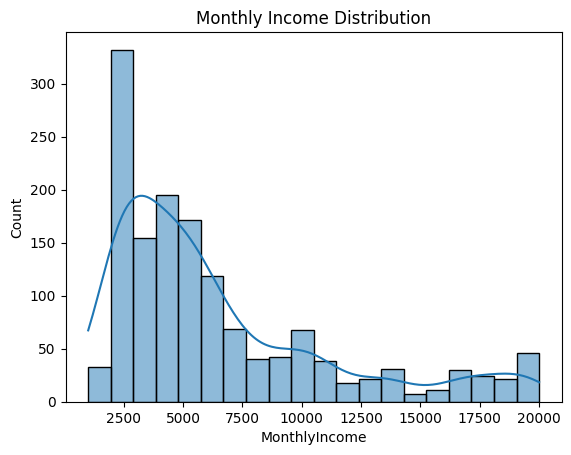

In [16]:
sns.histplot(df['MonthlyIncome'], kde=True)
plt.title("Monthly Income Distribution")
plt.show()

* Monthly income is right-skewed, meaning most employees earn on the lower end while a smaller group of senior employees earns significantly more.

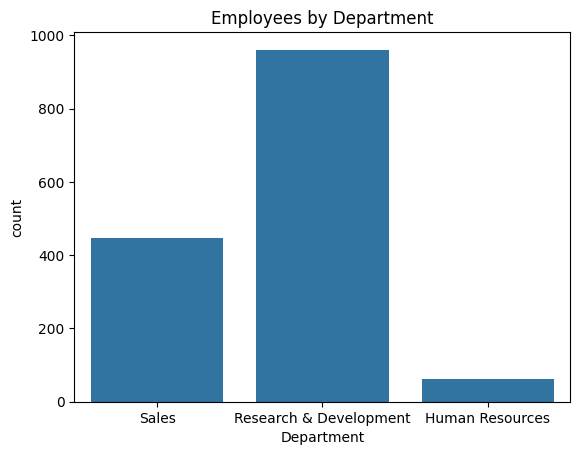

In [17]:
sns.countplot(x='Department', data=df)
plt.title("Employees by Department")
plt.show()

* Research & Development has the largest headcount, followed by Sales, while Human Resources is the smallest department.

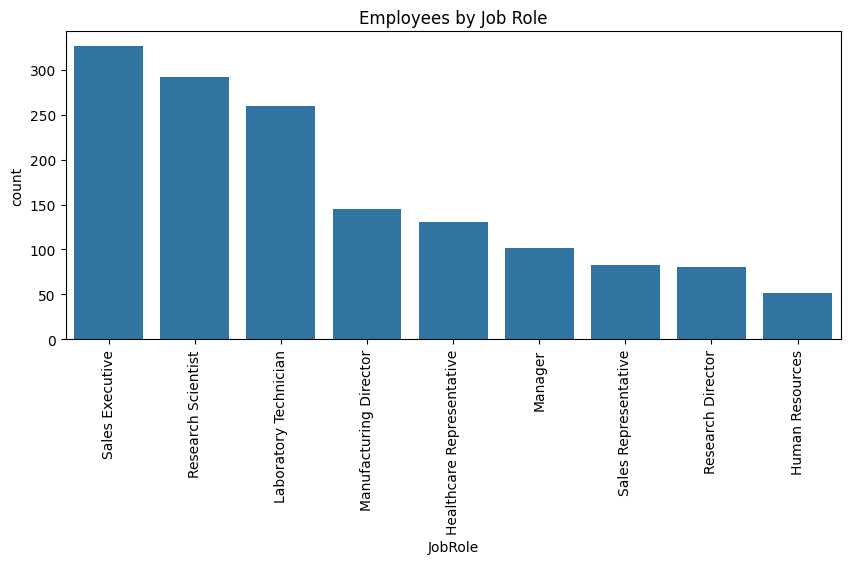

In [18]:
plt.figure(figsize=(10,4))
sns.countplot(x='JobRole', data=df)
plt.xticks(rotation=90)
plt.title("Employees by Job Role")
plt.show()

* Sales Executive and Research Scientist are the most common job roles, while Human Resources and Research Director have the fewest employees.

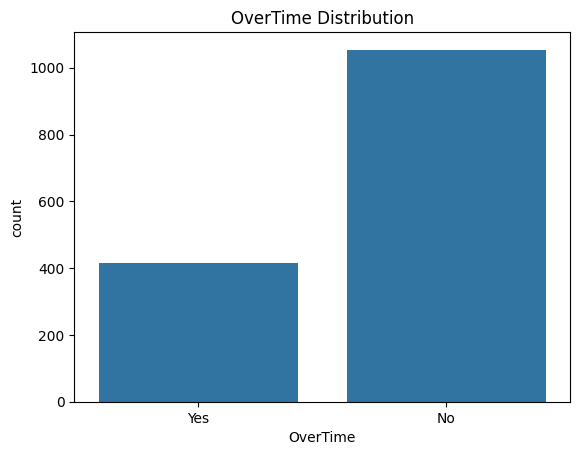

In [19]:
sns.countplot(x='OverTime', data=df)
plt.title("OverTime Distribution")
plt.show()

* The majority of employees do not work overtime, with only about a quarter working overtime regularly.

### Bivariate Analysis

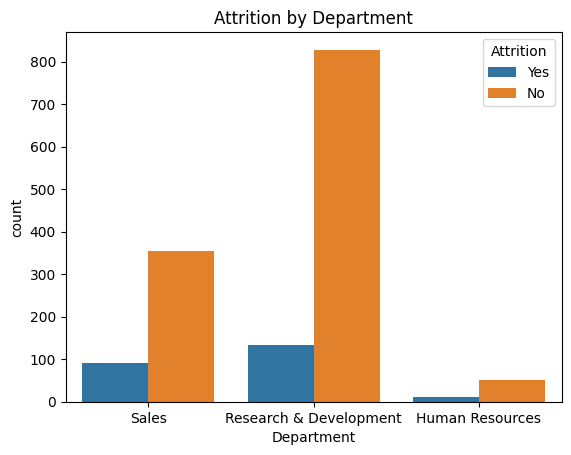

In [20]:
sns.countplot(x='Department', hue='Attrition', data=df)
plt.title("Attrition by Department")
plt.show()

* Sales and Research & Development show a visibly higher count of attrition compared to Human Resources, largely because those departments are bigger.

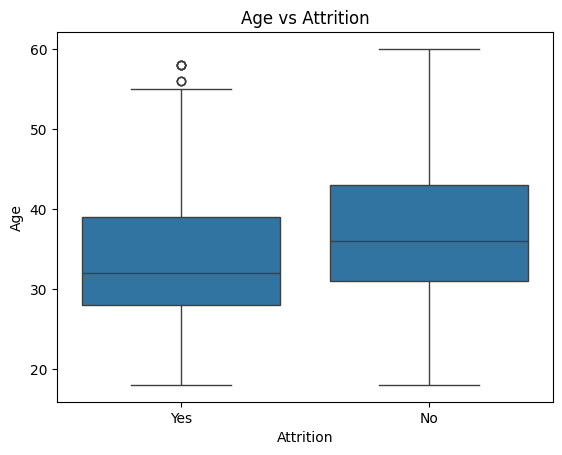

In [21]:
sns.boxplot(x='Attrition', y='Age', data=df)
plt.title("Age vs Attrition")
plt.show()

* Employees who leave the company tend to be younger on average than employees who stay.

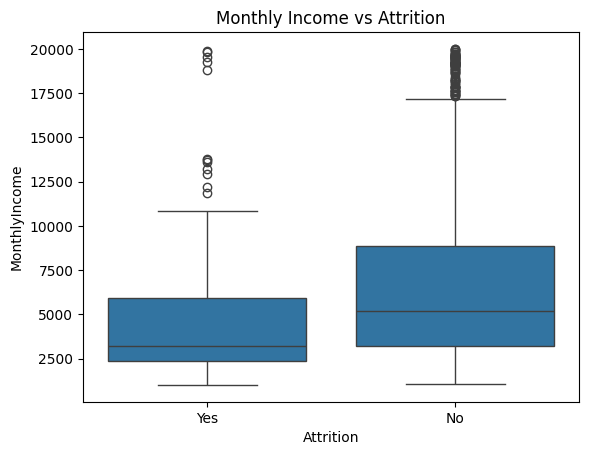

In [22]:
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title("Monthly Income vs Attrition")
plt.show()

* Employees with lower monthly income show a noticeably higher tendency to leave the organization.

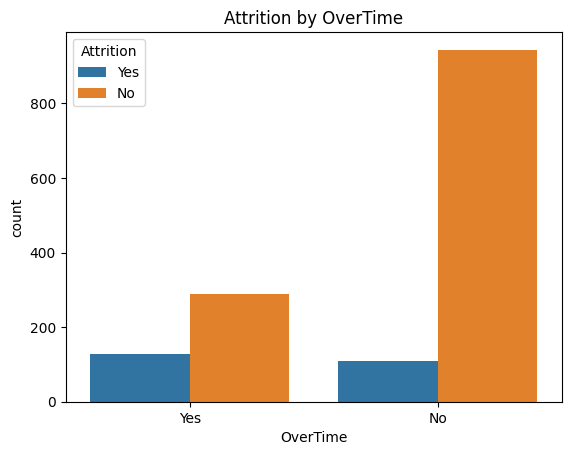

In [23]:
sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.title("Attrition by OverTime")
plt.show()

* Employees who work overtime leave at a much higher rate than those who do not, making OverTime a strong attrition indicator.

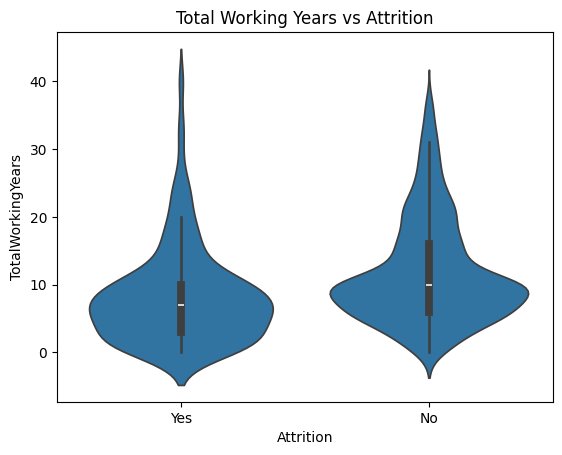

In [24]:
sns.violinplot(x='Attrition', y='TotalWorkingYears', data=df)
plt.title("Total Working Years vs Attrition")
plt.show()

* Employees with fewer total working years are more concentrated in the attrition group, showing early-career employees leave more often.

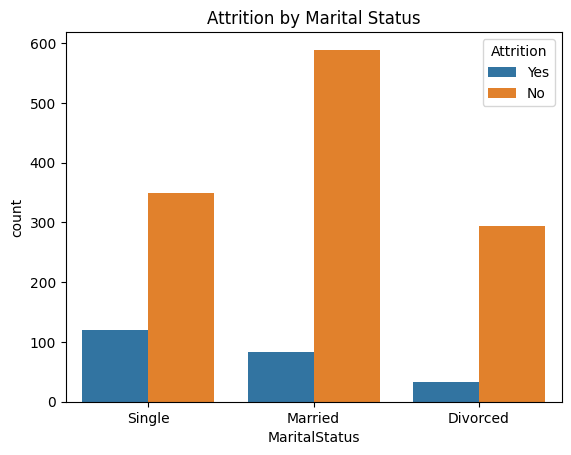

In [25]:
sns.countplot(x='MaritalStatus', hue='Attrition', data=df)
plt.title("Attrition by Marital Status")
plt.show()

* Single employees have a higher attrition rate relative to their group size compared to married or divorced employees.

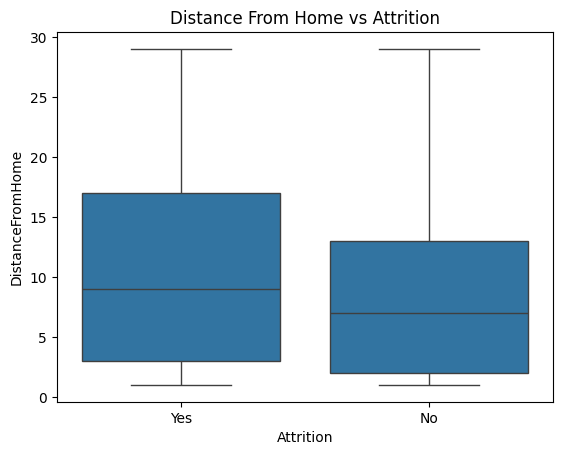

In [26]:
sns.boxplot(x='Attrition', y='DistanceFromHome', data=df)
plt.title("Distance From Home vs Attrition")
plt.show()

* Employees who leave tend to live slightly farther from the office than employees who stay.

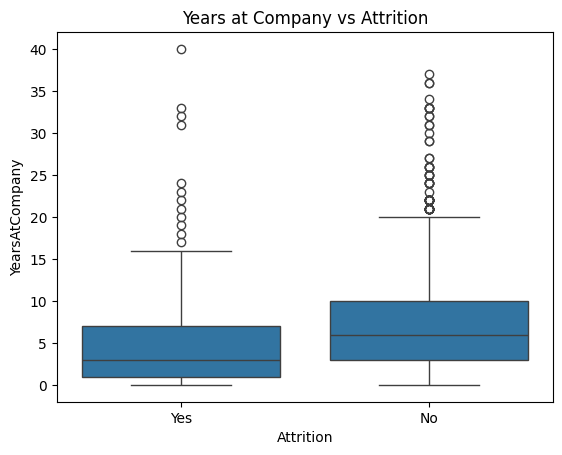

In [27]:
sns.boxplot(x='Attrition', y='YearsAtCompany', data=df)
plt.title("Years at Company vs Attrition")
plt.show()

* Attrition is highest among employees who have spent fewer years at the company, indicating a higher turnover risk early in tenure.

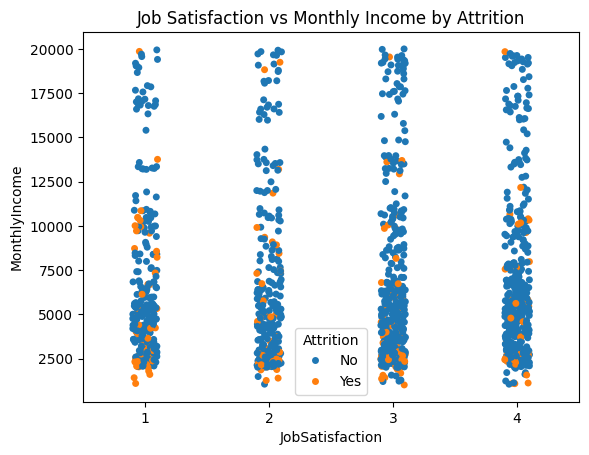

In [28]:
sns.stripplot(x='JobSatisfaction', y='MonthlyIncome', data=df, hue='Attrition')
plt.title("Job Satisfaction vs Monthly Income by Attrition")
plt.show()

* Employees who leave are spread across all satisfaction levels but are more visible among lower income bands regardless of satisfaction score.

### Multivariate Analysis

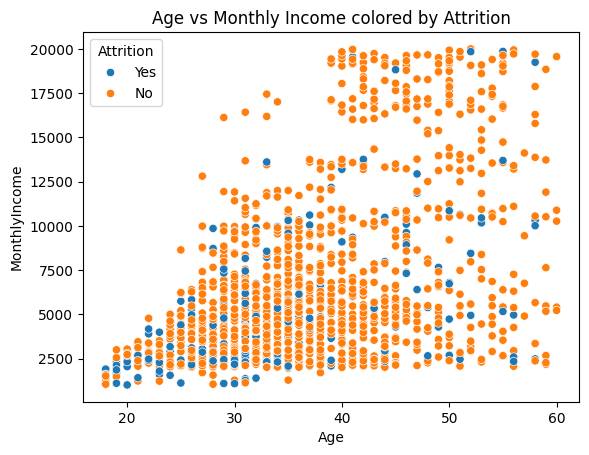

In [29]:
sns.scatterplot(x='Age', y='MonthlyIncome', hue='Attrition', data=df)
plt.title("Age vs Monthly Income colored by Attrition")
plt.show()

* Employees who leave are concentrated in the younger age and lower income region of the scatter plot.

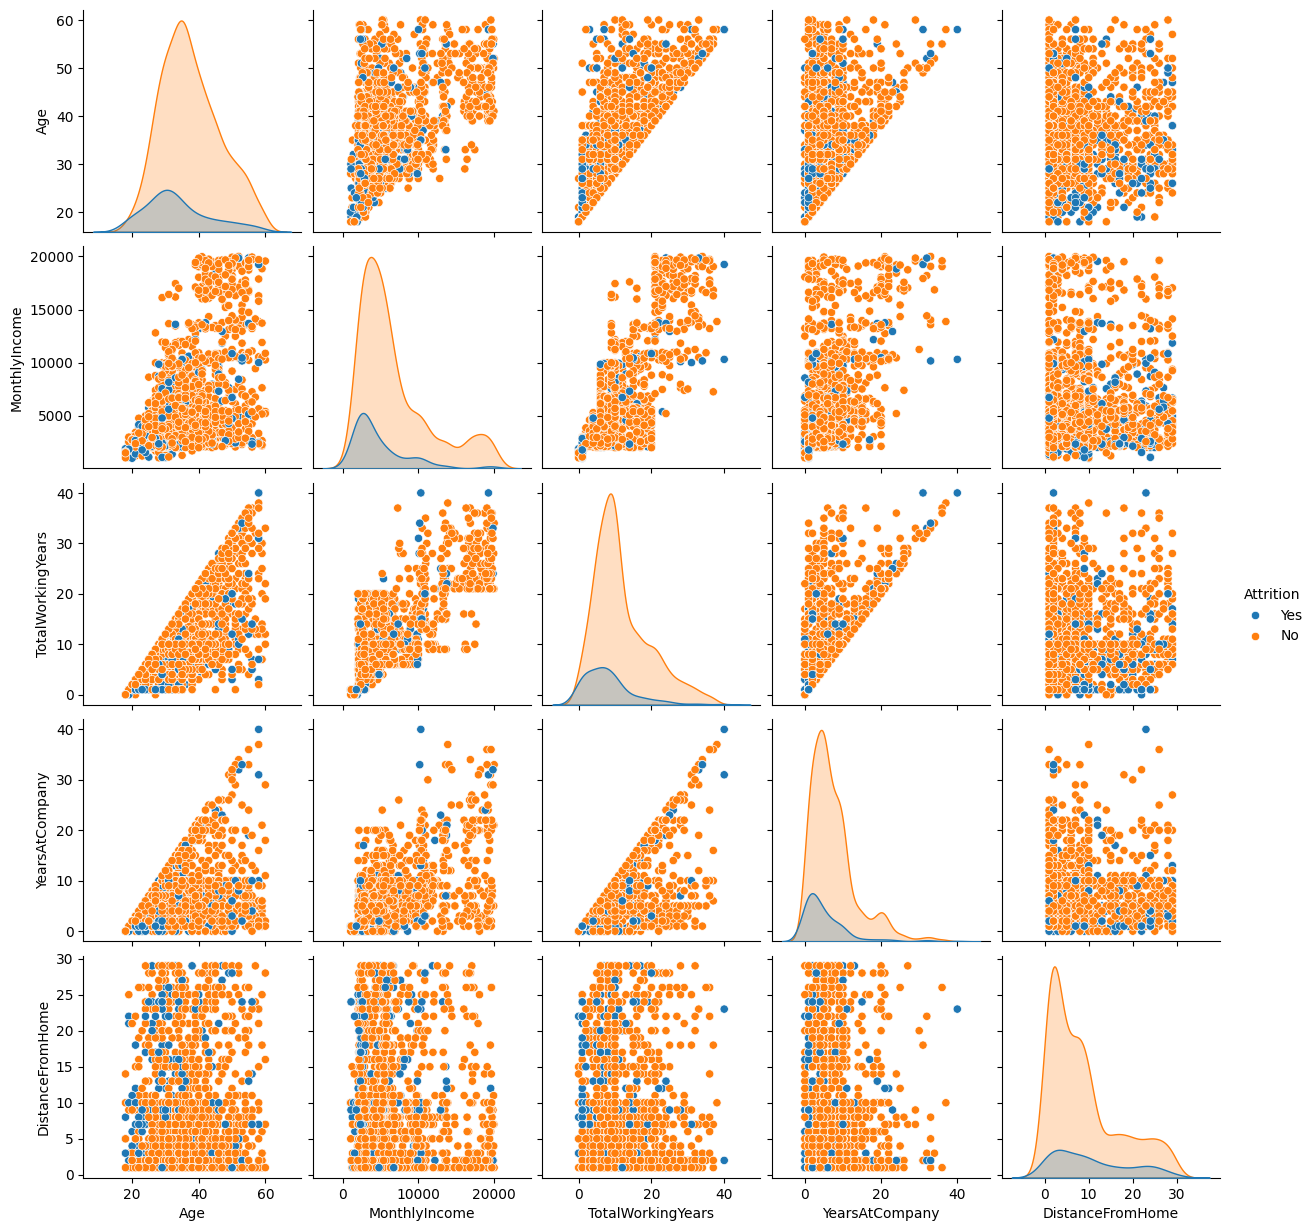

In [30]:
cols = ['Age','MonthlyIncome','TotalWorkingYears','YearsAtCompany','DistanceFromHome','Attrition']
sns.pairplot(df[cols], hue='Attrition')
plt.show()

* The pairplot shows attrition cases cluster toward lower age, lower income and fewer working/company years across nearly every feature pair.

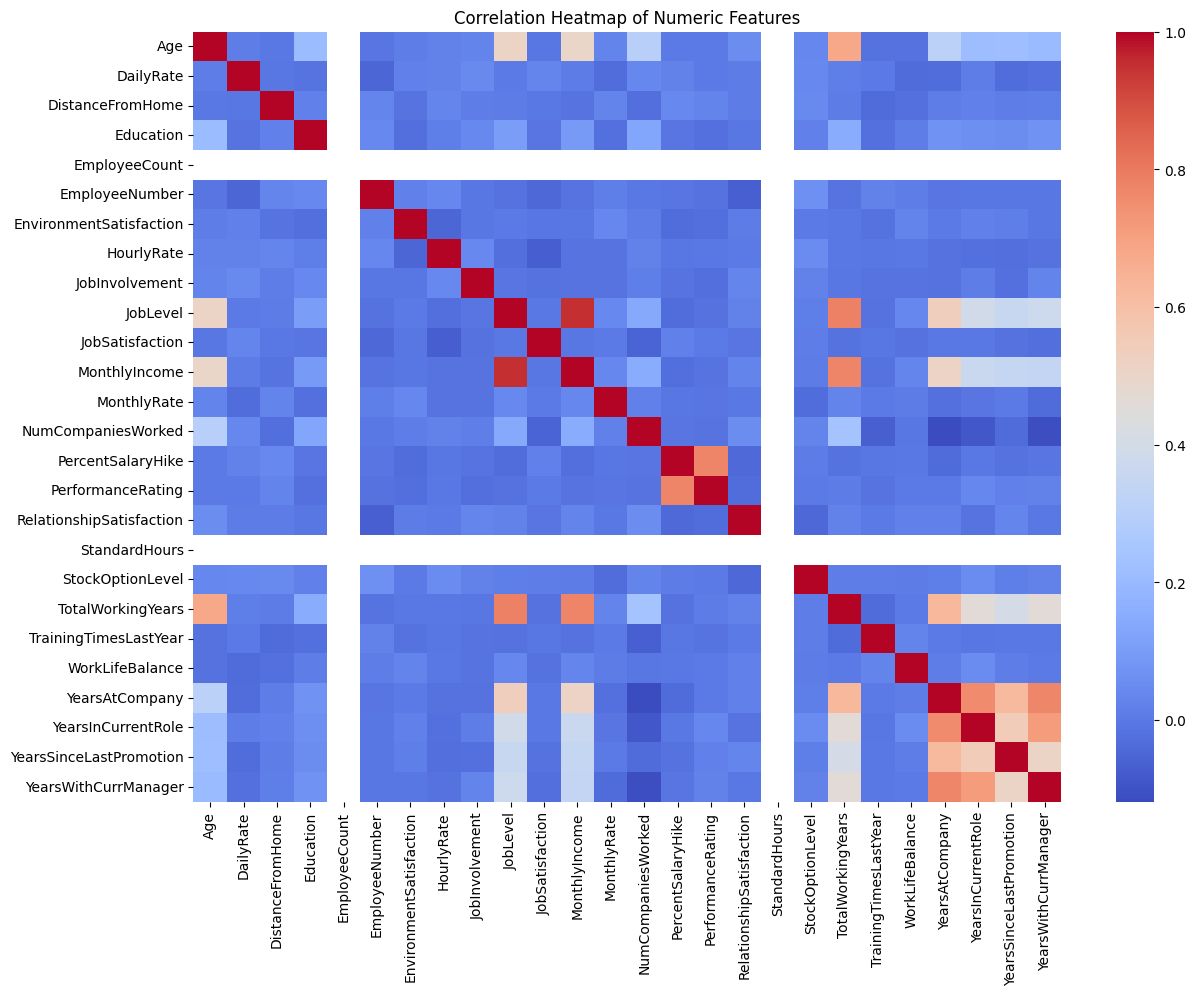

In [31]:
plt.figure(figsize=(14,10))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

* YearsAtCompany, YearsInCurrentRole, YearsWithCurrManager and TotalWorkingYears are all strongly positively correlated with each other, as expected for tenure-related features.

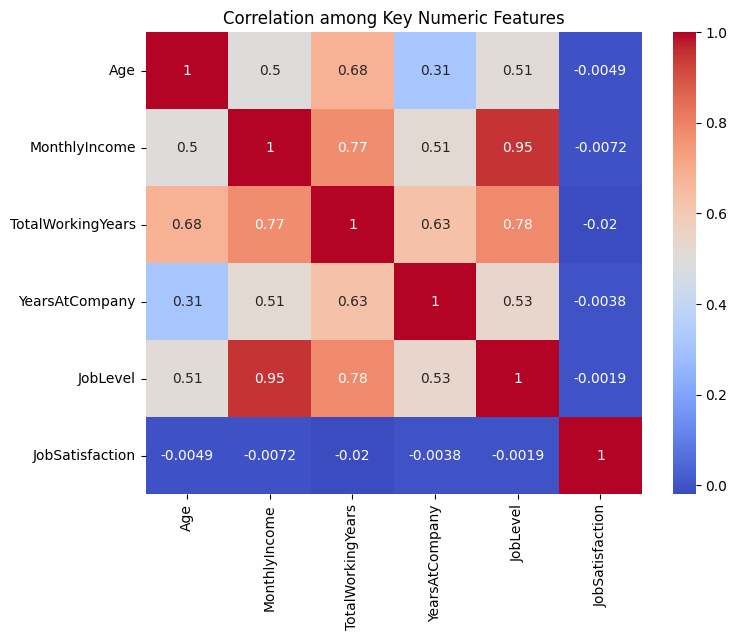

In [32]:
plt.figure(figsize=(8,6))
sub_corr = df[['Age','MonthlyIncome','TotalWorkingYears','YearsAtCompany','JobLevel','JobSatisfaction']].corr()
sns.heatmap(sub_corr, annot=True, cmap='coolwarm')
plt.title("Correlation among Key Numeric Features")
plt.show()

* JobLevel has a very strong positive correlation with MonthlyIncome, confirming that income increases consistently with job level.

### Outlier Detection

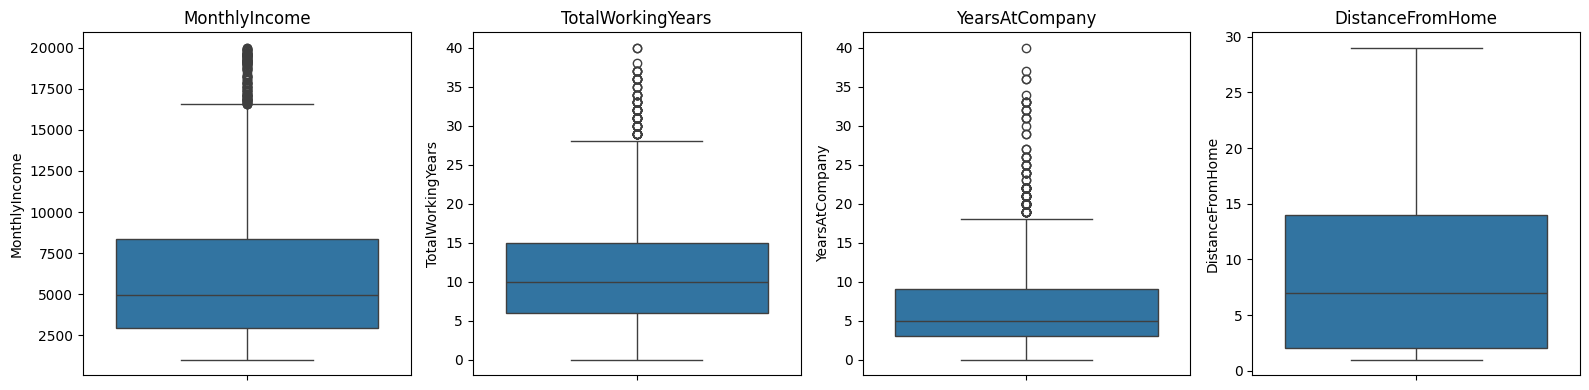

In [33]:
num_cols = ['MonthlyIncome','TotalWorkingYears','YearsAtCompany','DistanceFromHome']
plt.figure(figsize=(16,4))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

* MonthlyIncome, TotalWorkingYears, YearsAtCompany and DistanceFromHome all contain a number of high-end outliers, mostly coming from senior, long-tenured employees.